#  Task 2: Logistic Regression(Classification)
**Goal**:Build a classification model that predicts whether a titanic passenger survived, using the cleaned dataset from week 1-2.

## Step 1: import libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Step 2:Load Dataset
Loading the cleaned Titanic dataset.

In [3]:
titanic_df=pd.read_csv('Titanic-Cleaned.csv')
print("Shape:",titanic_df.shape)
titanic_df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.565736,1,0,A/5 21171,-0.700836,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,1,0,PC 17599,1.491434,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.258337,0,0,STON/O2. 3101282,-0.677726,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,1,0,113803,0.868903,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0.433312,0,0,373450,-0.673447,True,False,True


## Step 3:Data Cleaning Recap
Missing values, duplicates and categorical encoding(Sex,Embarked)were already handled.Now we just drop columns that are not useful as model inputs

In [4]:
print("Missing values per column:\n", titanic_df.isnull().sum())

model_df=titanic_df.drop(columns=['PassengerId', 'Name', 'Ticket'])
model_df.head()

Missing values per column:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Sex_male       0
Embarked_Q     0
Embarked_S     0
dtype: int64


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.565736,1,0,-0.700836,True,False,True
1,1,1,0.663861,1,0,1.491434,False,False,False
2,1,3,-0.258337,0,0,-0.677726,False,False,True
3,1,1,0.433312,1,0,0.868903,False,False,True
4,0,3,0.433312,0,0,-0.673447,True,False,True


## Step 4: Select Fearures and Target
- Features(X):Age,Fare,Passenger Class(Pclass),Sex(Sex_male)
- Target(Y):Survived

In [5]:
features=['Age','Fare','Pclass','Sex_male']
X=model_df[features]
Y=model_df['Survived']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", Y.value_counts())

Feature matrix shape: (891, 4)
Target distribution:
 Survived
0    549
1    342
Name: count, dtype: int64


## Step 5:Split the dataset
using the 80/20 

In [6]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2, random_state=42)
print(f"Training set:{X_train.shape[0]} rows")
print(f"Testing set:{X_test.shape[0]} rows")

Training set:712 rows
Testing set:179 rows


## Step 6: Train Logistic Regression Model

In [8]:
log_model= LogisticRegression(max_iter=1000)
log_model.fit(X_train, Y_train)
print("Coefficients:", dict(zip(features, log_model.coef_[0])))

Coefficients: {'Age': np.float64(-0.32931620320135047), 'Fare': np.float64(-0.00751612652387525), 'Pclass': np.float64(-1.0399109292781799), 'Sex_male': np.float64(-2.475828137640738)}


## Step 7:Make predictions

In [9]:
Y_pred=log_model.predict(X_test)

results=pd.DataFrame({'Actual':Y_test.values, 'Predicted':Y_pred})
results.head(10)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


## Step 8: Evaluate the Model

**Accuracy Score:** the proportion of correct predictions out of all predictions made. A higher accuracy means the model correctly classified more passengers as survived/did not survive.

We also include a confusion matrix and classification report for a fuller picture, since accuracy alone can be misleading.

Accuracy: 81.01%

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.87      0.84       105
       Survived       0.79      0.73      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



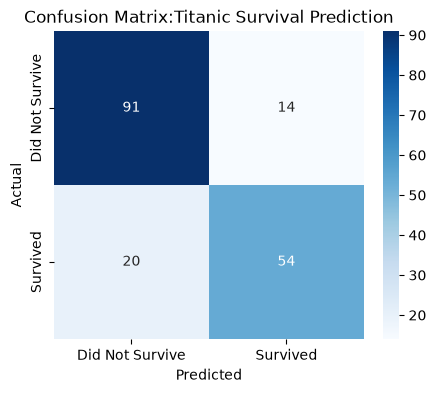

In [11]:
acc= accuracy_score(Y_test,Y_pred)
print(f"Accuracy: {acc:.2%}\n")

print("Classification Report:")
print(classification_report(Y_test,Y_pred, target_names=['Did Not Survive','Survived']))

cm=confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive','Survived'],
            yticklabels=['Did Not Survive','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix:Titanic Survival Prediction')
plt.show()
            